In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
%matplotlib inline
sns.set_style(style='whitegrid')
sns.set_context(context='notebook')
plt.rcParams['figure.figsize'] = (11, 9.4)

In [4]:
titanic_df = sns.load_dataset('titanic')
titanic_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


#CONTEOS

Conteo de todas las variables

In [5]:
titanic_df.describe(include='all')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Conteo de variables numéricas

In [6]:
titanic_df.describe(include=[np.number])

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Conteo de variables categóricas

In [7]:
titanic_df.describe(include=object)

,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


In [11]:
(
  titanic_df
    .astype(
        {
        'sex': 'category',
        'embarked' : 'category',
        'who' : 'category',
        'embark_town' : 'category',
        'alive' : 'category'
        }
    )
).describe(include=['category',object])

,sex,embarked,class,who,deck,embark_town,alive
count,891,889,891,891,203,889,891
unique,2,3,3,3,7,3,2
top,male,S,Third,man,C,Southampton,no
freq,577,644,491,537,59,644,549


Gráficos de conteos

In [13]:
sex_color = {
    'male': '#ff6602ff',
    'female': '#0f7175ff'
}

<Axes: xlabel='sex'>

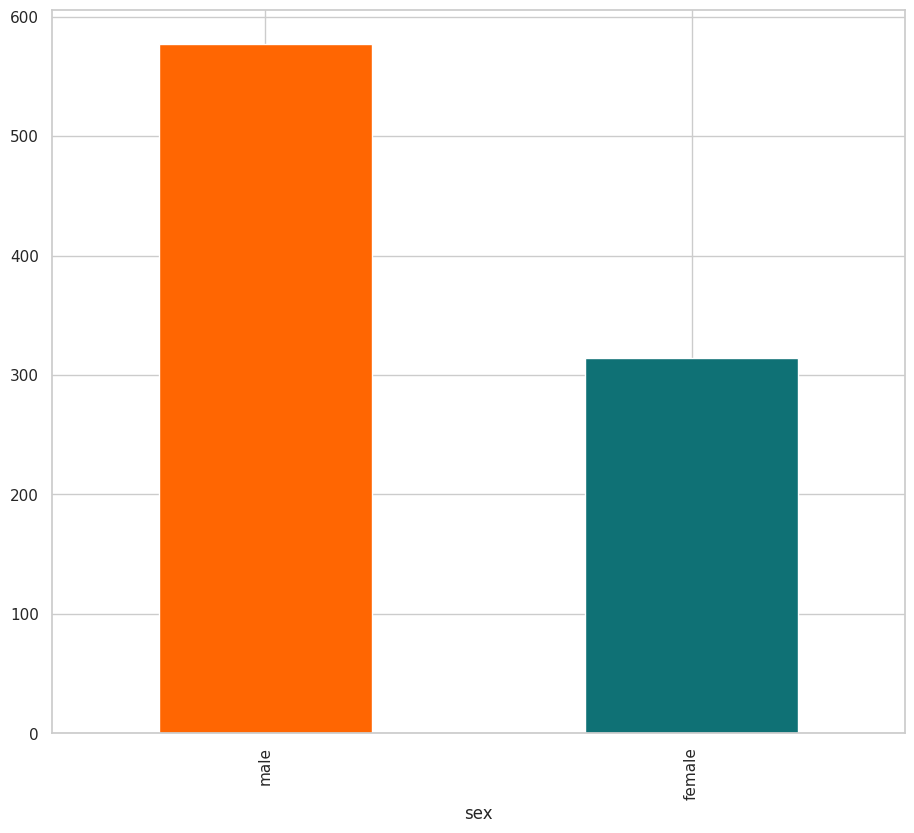

In [14]:
(
    titanic_df
    .sex
    .value_counts()
    .plot(
        kind='bar',
        color=sex_color.values()
    )
)

<ipython-input-15-d26bec9020f1>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='sex', ylabel='count'>

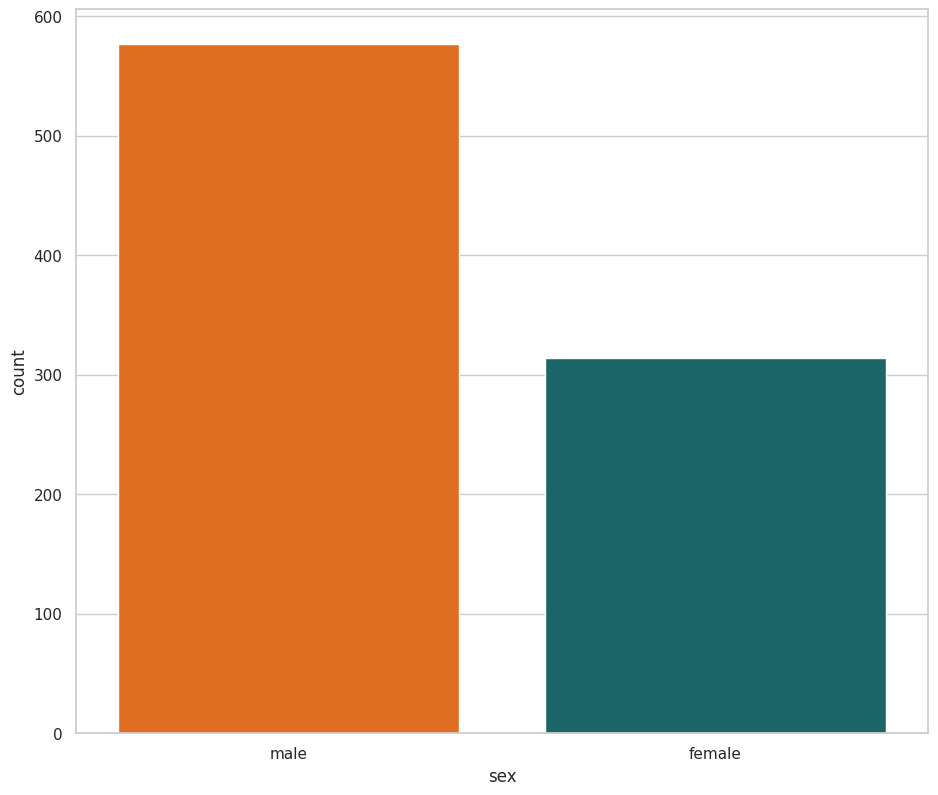

In [15]:
(
    titanic_df
    .value_counts('sex',sort=True)
    .reset_index(name='count')
    .pipe(
        lambda df :(
            sns.barplot(
                data=df,
                x='sex',
                y='count',
                palette=sex_color
            )
        )
    )
)

Gráfico conteo de embarked

In [19]:
embarked_color = {
    'S': '#ff6602ff',
    'C': '#0f7175ff',
    'Q': '#c65dc9ff'
}

<ipython-input-20-12e1b1cb9eaf>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='embarked', ylabel='count'>

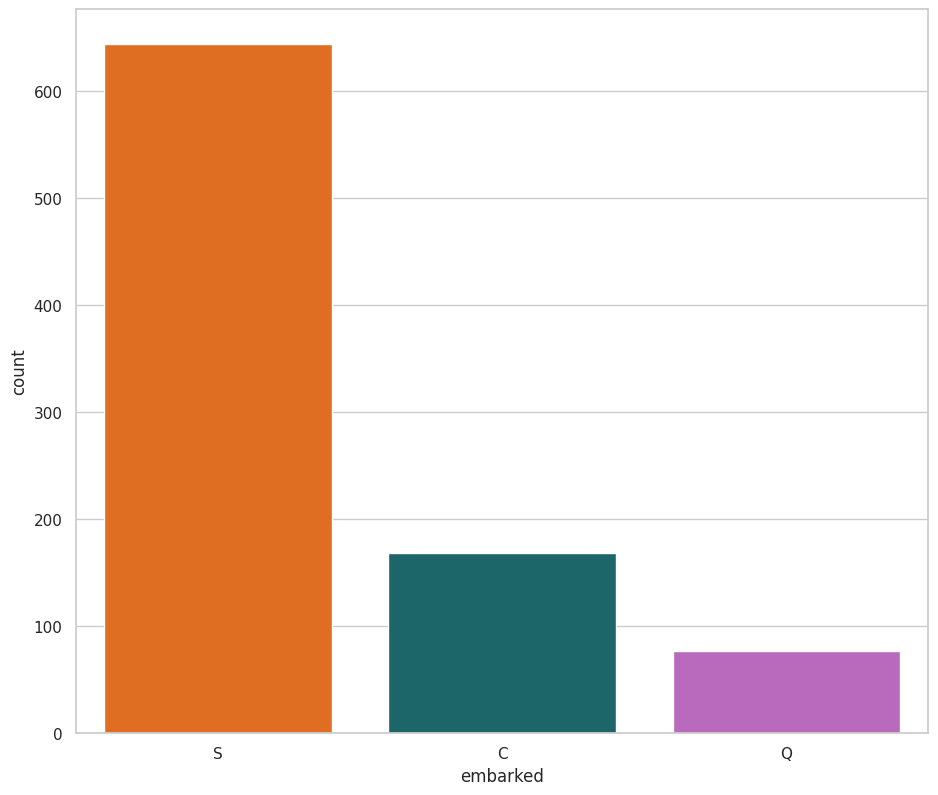

In [20]:
(
    titanic_df
    .value_counts('embarked',sort=True)
    .reset_index(name='count')
    .pipe(
        lambda df :(
            sns.barplot(
                data=df,
                x='embarked',
                y='count',
                palette=embarked_color
            )
        )
    )
)

In [30]:
class_color = {
    'First': '#ff6602ff',
    'Second': '#0f7175ff',
    'Third': '#c65dc9ff'
}

<ipython-input-31-0ac6eee0ac3a>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='class', ylabel='count'>

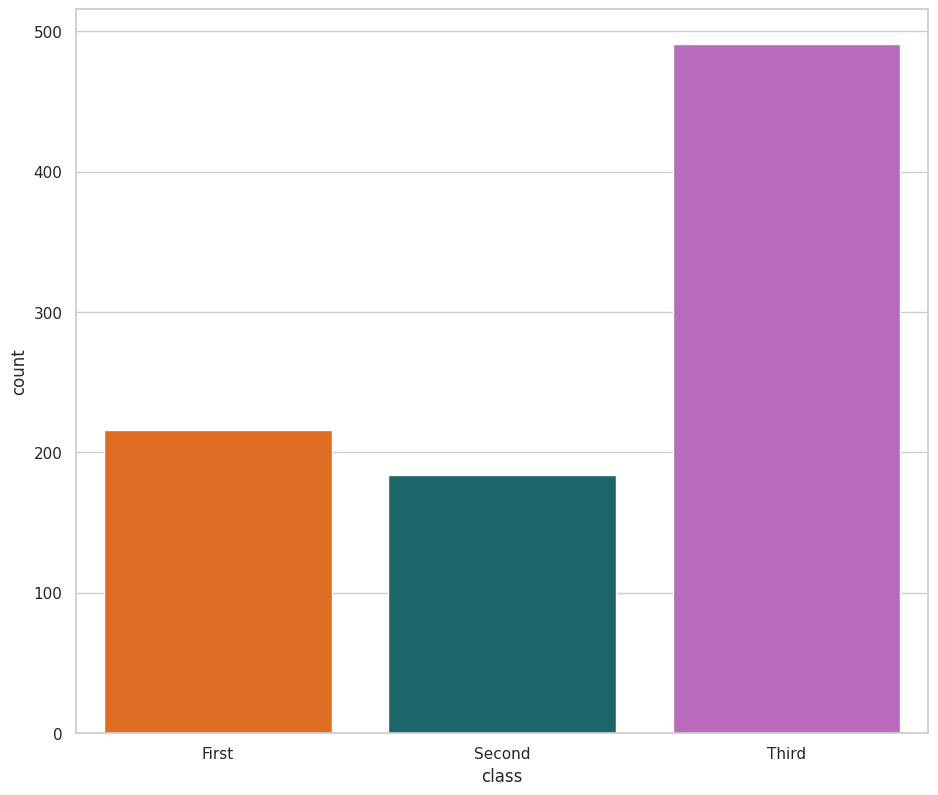

In [31]:
(
    titanic_df
    .value_counts('class',sort=True)
    .reset_index(name='count')
    .pipe(
        lambda df :(
            sns.barplot(
                data=df,
                x='class',
                y='count',
                palette=class_color
            )
        )
    )
)

In [35]:
who_color = {
    'man': '#ff6602ff',
    'woman': '#0f7175ff',
    'child': '#c65dc9ff'
}

<ipython-input-36-9c9d6e2b05dc>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='who', ylabel='count'>

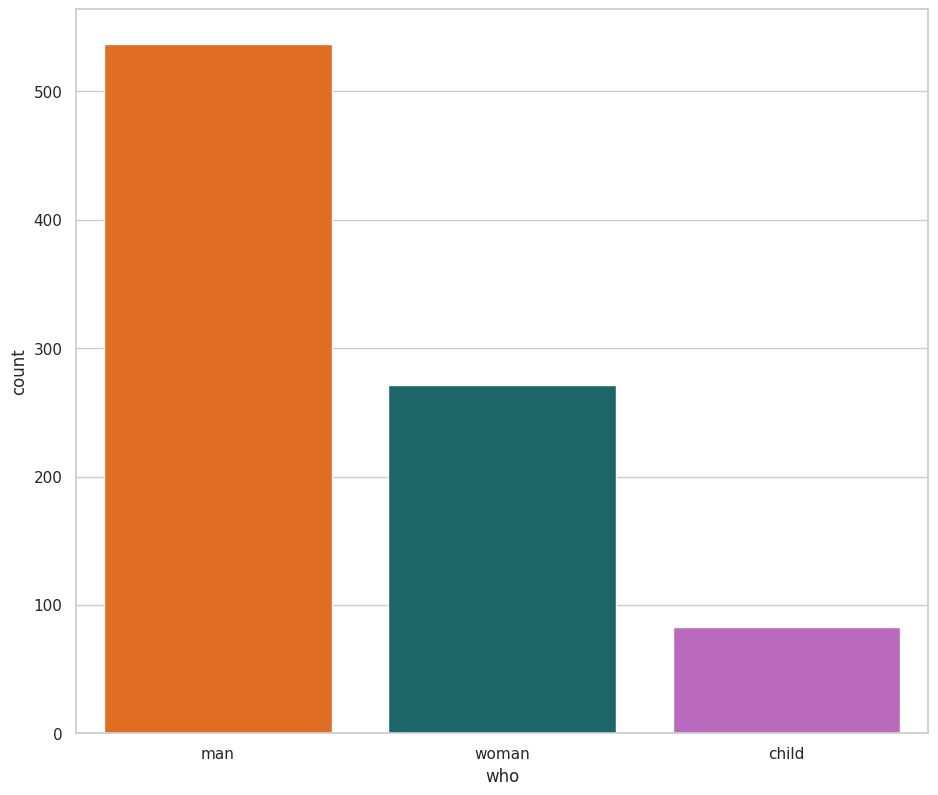

In [36]:
(
    titanic_df
    .value_counts('who',sort=True)
    .reset_index(name='count')
    .pipe(
        lambda df :(
            sns.barplot(
                data=df,
                x='who',
                y='count',
                palette=who_color
            )
        )
    )
)

In [40]:
alive_color = {
    'yes': '#ff6602ff',
    'no': '#0f7175ff',
}

<ipython-input-41-1e2863b6e251>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Axes: xlabel='alive', ylabel='count'>

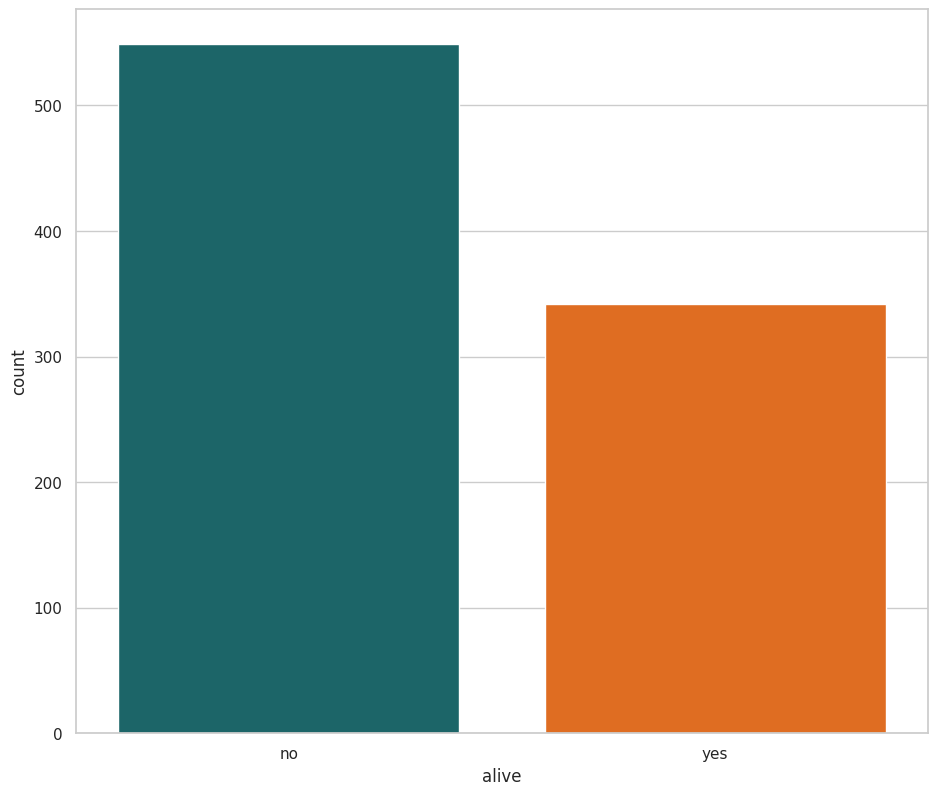

In [41]:
(
    titanic_df
    .value_counts('alive',sort=True)
    .reset_index(name='count')
    .pipe(
        lambda df :(
            sns.barplot(
                data=df,
                x='alive',
                y='count',
                palette=alive_color
            )
        )
    )
)

#PROPORCIONES

In [21]:
titanic_df['variable'] = ''
titanic_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,variable
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,


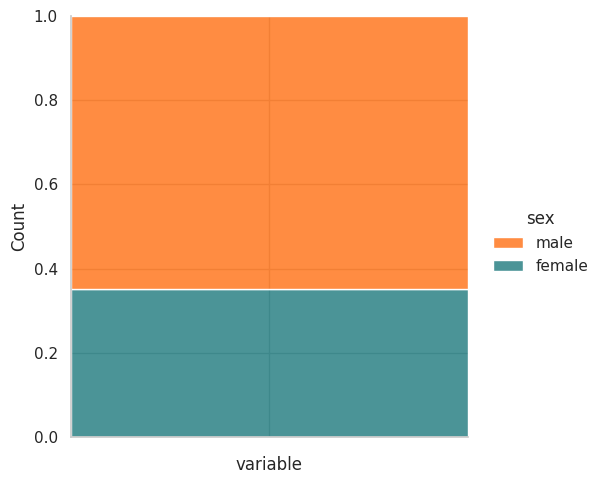

In [22]:
(
    titanic_df
    .pipe(
        lambda df: (
            sns.displot(
                data=df,
                x='variable',
                hue='sex',
                multiple='fill',
                palette=sex_color
            )
        )
    )
)

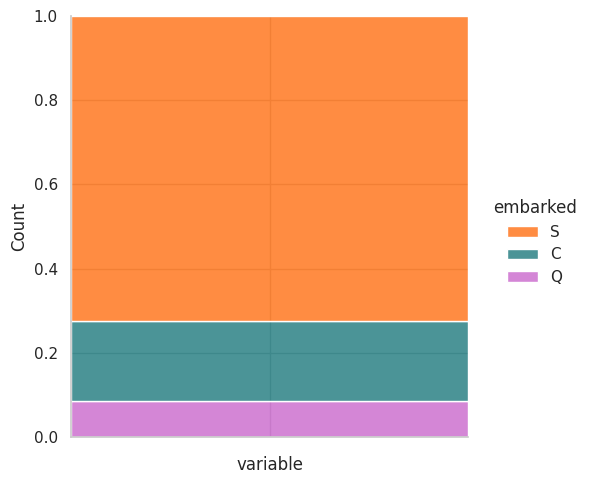

In [23]:
(
    titanic_df
    .pipe(
        lambda df: (
            sns.displot(
                data=df,
                x='variable',
                hue='embarked',
                multiple='fill',
                palette=embarked_color
            )
        )
    )
)

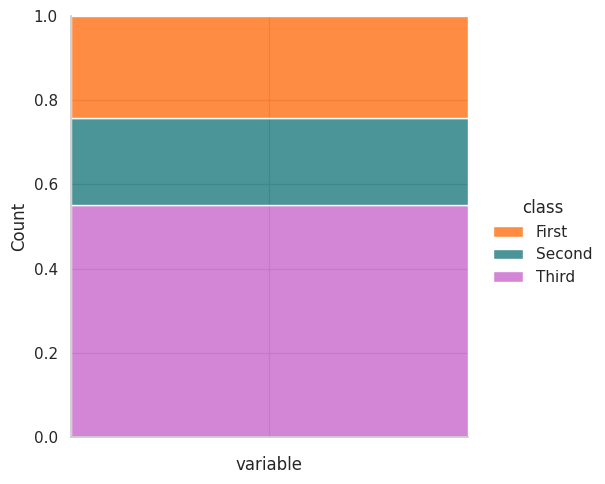

In [37]:
(
    titanic_df
    .pipe(
        lambda df: (
            sns.displot(
                data=df,
                x='variable',
                hue='class',
                multiple='fill',
                palette=class_color
            )
        )
    )
)

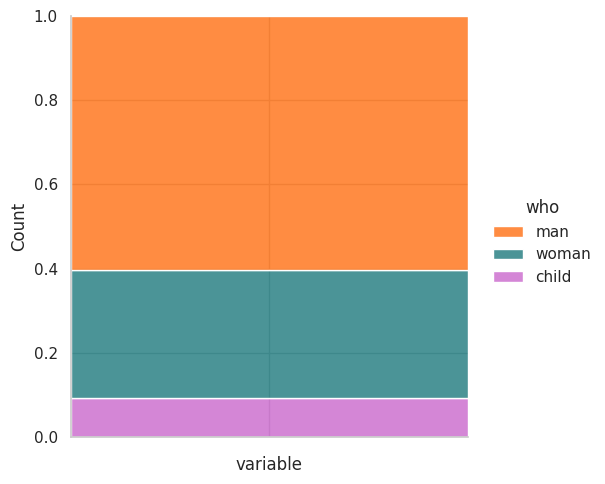

In [38]:
(
    titanic_df
    .pipe(
        lambda df: (
            sns.displot(
                data=df,
                x='variable',
                hue='who',
                multiple='fill',
                palette=who_color
            )
        )
    )
)

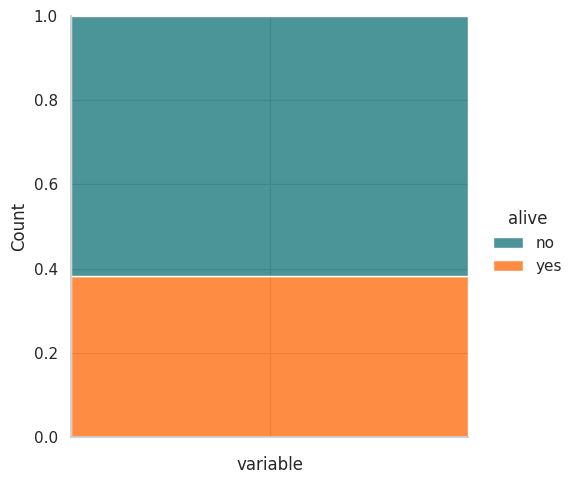

In [42]:
(
    titanic_df
    .pipe(
        lambda df: (
            sns.displot(
                data=df,
                x='variable',
                hue='alive',
                multiple='fill',
                palette=alive_color
            )
        )
    )
)